In [26]:
from ultralytics import YOLO
import cv2 as cv2
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image
import time
import supervision as sv
import torch
from transformers import AutoProcessor, AutoModelForDepthEstimation
import gdown

3.1.1 Draw the segmentation mask of the largest car: Use ultralytics library only

In [36]:
img = cv2.imread("demo5_images/cars1.jpg")

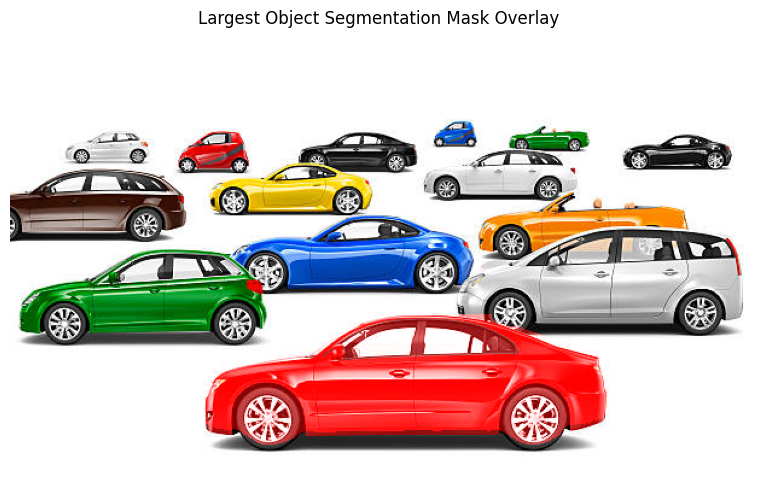

In [37]:
# Load YOLOv8 Segmentation Model
model = YOLO("yolov8n-seg.pt")  # Ensure correct model

if img is None:
    raise ValueError("Error: Image not found. Check the path.")

image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Run YOLO Segmentation Model
results = model.predict(source=img, verbose=False)
result = results[0]

# Get Bounding Boxes
boxes = result.boxes.xyxy.cpu().numpy()

# Find the Largest Detected Object
largest_area = 0
largest_index = -1

for idx, box in enumerate(boxes):
    x1, y1, x2, y2 = box
    area = (x2 - x1) * (y2 - y1)
    if area > largest_area:
        largest_area = area
        largest_index = idx

if largest_index == -1:
    print("No objects detected!")
else:
    if result.masks is not None:
        # Retrieve the segmentation mask and resize it
        mask = result.masks.data[largest_index].cpu().numpy()
        binary_mask = (mask > 0.5).astype(np.uint8)

        # Resize mask to match original image dimensions
        binary_mask = cv2.resize(binary_mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

        # Create an overlay color (Red)
        overlay_color = np.zeros_like(img, dtype=np.uint8)
        overlay_color[binary_mask == 1] = (0, 0, 255)  # Red color (BGR)

        # Blend image and mask
        alpha = 0.5
        result_img = cv2.addWeighted(img, 1.0, overlay_color, alpha, 0)

        # Convert to RGB for displaying in Jupyter Notebook
        result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

        # Display the image inline in Jupyter Notebook
        plt.figure(figsize=(10, 6))
        plt.imshow(result_img_rgb)
        plt.axis("off")
        plt.title("Largest Object Segmentation Mask Overlay")
        plt.show()
    else:
        print("No segmentation masks available!")

3.1.2 Draw the segmentation mask of the largest car : Use ultralytics + supervision libraries

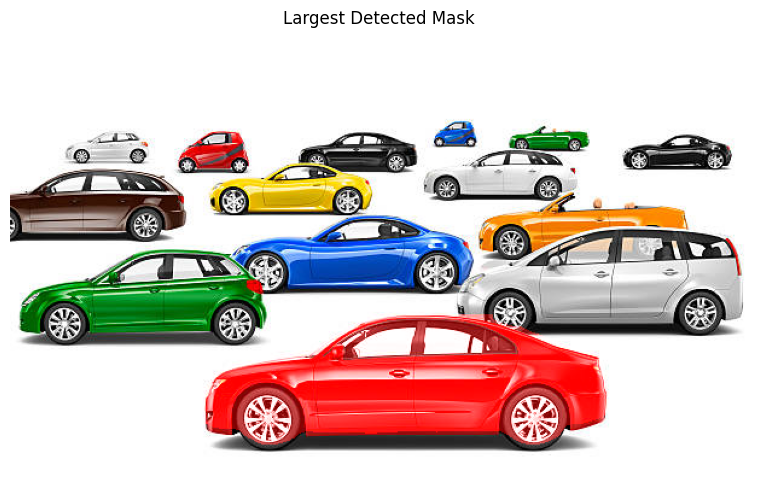

In [38]:
if img is None:
    raise ValueError("Image not found. Please check the image path.")

# Convert BGR to RGB for correct display in Matplotlib
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -------------------------
# 2. Load a pre-trained segmentation model from Ultralytics
# -------------------------
model = YOLO("yolov8n-seg.pt")  # Ensure this is a segmentation model

# Run the segmentation model on the image.
results = model.predict(source=img, verbose=False)
result = results[0]

# -------------------------
# 3. Transfer Ultralytics results to Supervision
# -------------------------
detections = sv.Detections.from_ultralytics(result)

# Ensure that the model has returned segmentation masks
if result.masks is not None:
    detections.masks = result.masks.data.cpu().numpy()
else:
    detections.masks = None

# -------------------------
# 4. Find the largest mask by area
# -------------------------
largest_area = 0
largest_mask = None

if detections.masks is None or len(detections.masks) == 0:
    print("No masks found in the segmentation results!")
else:
    for mask in detections.masks:
        binary_mask = (mask > 0.5).astype(np.uint8)

        # Resize mask if dimensions do not match the original image
        if binary_mask.shape[:2] != img.shape[:2]:
            binary_mask = cv2.resize(binary_mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        
        # Compute area
        area = np.count_nonzero(binary_mask)
        if area > largest_area:
            largest_area = area
            largest_mask = binary_mask

# -------------------------
# 5. Display the largest mask inside Jupyter Notebook
# -------------------------
if largest_mask is None:
    print("No valid masks to display!")
else:
    # Create an overlay image (Red mask)
    overlay_color = (255, 0, 0)  # Red in RGB
    colored_mask = np.zeros_like(img, dtype=np.uint8)
    for c in range(3):  # Apply to all channels
        colored_mask[:, :, c] = overlay_color[c] * largest_mask

    # Blend the original image with the mask
    alpha = 0.5
    result_img = cv2.addWeighted(img, 1.0, colored_mask, alpha, 0)

    # Display the image inside the notebook
    plt.figure(figsize=(10, 6))
    plt.imshow(result_img)
    plt.axis("off")  # Hide axes
    plt.title("Largest Detected Mask")
    plt.show()

3.2 Estimate distance to centroid of chair 


0: 384x640 1 chair, 482.2ms
Speed: 1.0ms preprocess, 482.2ms inference, 6.0ms postprocess per image at shape (1, 3, 384, 640)
Centroid of the largest chair: (352, 183)
Depth at centroid (352, 183): 7.79 meters


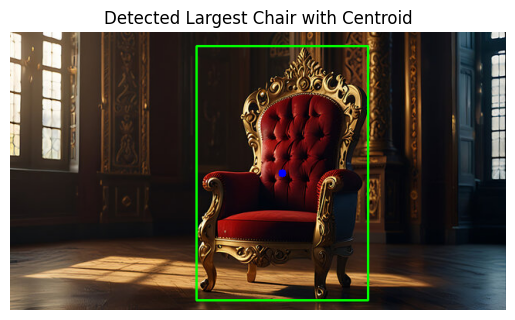

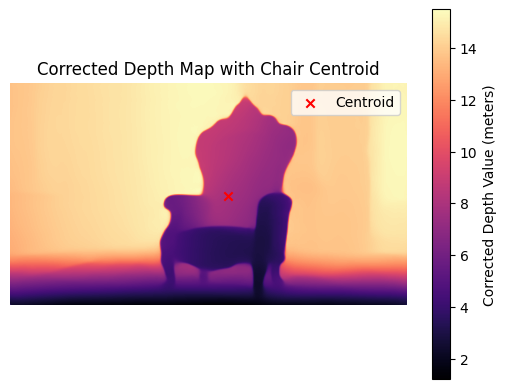

In [39]:
# Load YOLOv8 model
model = YOLO('yolov8m-seg.pt')

# Load the image
image_path = "demo5_images/kingChair.jpg"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Run YOLOv8 on the image
results = model(image_rgb)

# Find the largest chair by area
largest_chair = None
largest_area = 0

for result in results:
    for i in range(len(result.boxes)):
        cls = int(result.boxes.cls[i])
        if model.names[cls] == "chair":
            x_min, y_min, x_max, y_max = map(int, result.boxes.xyxy[i])  # Get bounding box coordinates
            area = (x_max - x_min) * (y_max - y_min)  # Calculate bounding box area
            if area > largest_area:
                largest_area = area
                largest_chair = (x_min, y_min, x_max, y_max)

if largest_chair is None:
    print("No chair detected!")
    exit()

# Get coordinates of the largest chair
x_min, y_min, x_max, y_max = largest_chair
centroid_x = (x_min + x_max) // 2
centroid_y = (y_min + y_max) // 2
print(f"Centroid of the largest chair: ({centroid_x}, {centroid_y})")

# Load Depth Anything V2 Model
processor = AutoProcessor.from_pretrained("LiheYoung/depth-anything-small-hf")
depth_model = AutoModelForDepthEstimation.from_pretrained("LiheYoung/depth-anything-small-hf")

# The image was already converted to RGB format

# Process image to obtain depth map
inputs = processor(image_rgb, return_tensors="pt")
with torch.no_grad():
    depth_output = depth_model(**inputs).predicted_depth

# Convert depth map to NumPy
depth_map = depth_output.squeeze().cpu().numpy()

# Resize depth map to match original image
depth_map_resized = cv2.resize(depth_map, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_LINEAR)

# Fix inverted depth: Flip min and max depth
min_depth = depth_map_resized.min()
max_depth = depth_map_resized.max()
depth_map_corrected = max_depth + min_depth - depth_map_resized  # Correct inversion

# Check if the centroid is within bounds of depth map
if 0 <= centroid_x < depth_map_resized.shape[1] and 0 <= centroid_y < depth_map_resized.shape[0]:
    depth_value = depth_map_corrected[centroid_y, centroid_x]
    print(f"Depth at centroid ({centroid_x}, {centroid_y}): {depth_value:.2f} meters")
else:
    print("Error: Centroid out of depth map bounds!")

# Visualize the largest chair's bounding box and centroid on the image
cv2.rectangle(image_rgb, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)  # Green bounding box
cv2.circle(image_rgb, (centroid_x, centroid_y), 5, (0, 0, 255), -1)  # Red centroid circle

# Show the image with bounding box and centroid
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Detected Largest Chair with Centroid")
plt.show()

# Show the depth map with centroid
plt.imshow(depth_map_corrected, cmap="magma")
plt.colorbar(label="Corrected Depth Value (meters)")
plt.scatter(centroid_x, centroid_y, color="red", marker="x", label="Centroid")
plt.legend()
plt.axis("off")
plt.title("Corrected Depth Map with Chair Centroid")
plt.show()

3.3.1  Draw bounding boxes around the "cars" using supervision. 

In [14]:
# Downloads the video file from the google drive link, you'll have to "pip install gdown" first

file_id = "1zcKvnDDEdyFF4B0B3eYud6DHU19nl0o4"
direct_url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(direct_url, "vehicles_video.mp4", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1zcKvnDDEdyFF4B0B3eYud6DHU19nl0o4
To: c:\Users\ACER\Desktop\Work\Uni\USJ\Year 4\Semester 8\Machine Vision Systems\Assignment\THA3\Assignment\vehicles_video.mp4
100%|██████████| 35.3M/35.3M [00:47<00:00, 749kB/s] 


'vehicles_video.mp4'

In [33]:
# Load YOLO model
model = YOLO("yolo11n.pt")

# Create Box Annotator
annotator = sv.BoxAnnotator()

def callback(frame: np.ndarray, _: int) -> np.ndarray:
    # Step 1: Run YOLO on the frame
    results = model(frame)[0]  # Get first result from YOLO

    # Step 2: Convert YOLO detections to Supervision format
    detections = sv.Detections.from_ultralytics(results)

    # Step 3: Filter only cars using YOLO's class ID
    CAR_CLASS_ID = 2  # ID from YOLO model's class mappings
    detections = detections[detections.class_id == CAR_CLASS_ID]

    # Step 4: Draw bounding boxes around detected cars
    annotated_frame = annotator.annotate(
        scene=frame, 
        detections=detections
    )

    return annotated_frame

# Process video and save output with bounding boxes
sv.process_video(
    source_path="vehicles_video.mp4",
    target_path="vehicles_video_WithBoundingBoxes.mp4",
    callback=callback
)

print("Bounding boxes around cars added. Output saved as 'vehicles_video_WithCoundingBoxes.mp4'")


0: 384x640 3 cars, 1 truck, 71.8ms
Speed: 5.3ms preprocess, 71.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 1 truck, 72.5ms
Speed: 3.0ms preprocess, 72.5ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 66.4ms
Speed: 3.0ms preprocess, 66.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 66.5ms
Speed: 3.0ms preprocess, 66.5ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 59.5ms
Speed: 2.0ms preprocess, 59.5ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 62.4ms
Speed: 3.0ms preprocess, 62.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 57.9ms
Speed: 2.9ms preprocess, 57.9ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 62.9ms
Speed: 3.4ms preprocess, 62.9ms i

3.3.1 Track the cars. Add the tracker id to the bounding boxes around the cars. Use supervision

In [34]:
# Load YOLO model
model = YOLO("yolo11n.pt")

# Create Tracker (ByteTrack from Supervision)
tracker = sv.ByteTrack()

# Create Box Annotator for drawing bounding boxes
annotator = sv.BoxAnnotator()

def callback(frame: np.ndarray, _: int) -> np.ndarray:
    # Step 1: Run YOLO on the frame
    results = model(frame)[0]

    # Step 2: Convert YOLO detections to Supervision format
    detections = sv.Detections.from_ultralytics(results)

    # Step 3: Filter only cars using YOLO's class ID
    CAR_CLASS_ID = 2
    detections = detections[detections.class_id == CAR_CLASS_ID]

    # Step 4: Track cars and assign unique Tracker IDs
    tracked_detections = tracker.update_with_detections(detections)

    # Step 5: Draw bounding boxes
    annotated_frame = annotator.annotate(
        scene=frame, 
        detections=tracked_detections
    )

    # Step 6: Manually draw Tracker IDs using `sv.draw_text`
    for i, tracker_id in enumerate(tracked_detections.tracker_id):
        x, y, _, _ = tracked_detections.xyxy[i]  # Get bounding box coordinates
        sv.draw_text(
            scene=annotated_frame,
            text=f"Car ID {tracker_id}",
            text_anchor=sv.Point(int(x), int(y) - 10),
            text_scale=1,
            text_thickness=2,
            text_color=sv.Color.RED
        )

    return annotated_frame

# Process video and save output with tracked cars
sv.process_video(
    source_path="vehicles_video.mp4",
    target_path="vehicles_video_TrackedCars.mp4",
    callback=callback
)

print("Car tracking completed! Output saved as 'vehicles_video_TrackedCars.mp4'.")


0: 384x640 3 cars, 1 truck, 171.8ms
Speed: 57.0ms preprocess, 171.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 1 truck, 87.5ms
Speed: 4.0ms preprocess, 87.5ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 75.6ms
Speed: 4.0ms preprocess, 75.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 71.0ms
Speed: 2.0ms preprocess, 71.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 65.7ms
Speed: 2.0ms preprocess, 65.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 62.6ms
Speed: 3.0ms preprocess, 62.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 64.4ms
Speed: 2.0ms preprocess, 64.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 90.3ms
Speed: 4.0ms preprocess, 90.3m

3.3.2 Draw the track traces for the tracked cars. Use supervision

In [35]:
# Load YOLO model
model = YOLO("yolo11n.pt")

# Create a Tracker (ByteTrack from Supervision)
tracker = sv.ByteTrack()

# Create Box Annotator for drawing bounding boxes and labels
annotator = sv.BoxAnnotator()

# Dictionary to store track traces
track_traces = {}

def callback(frame: np.ndarray, _: int) -> np.ndarray:
    # Step 1: Run YOLO on the frame
    results = model(frame)[0]

    # Step 2: Convert YOLO detections to Supervision format
    detections = sv.Detections.from_ultralytics(results)

    # Step 3: Filter only cars using YOLO's class ID
    CAR_CLASS_ID = 2
    detections = detections[detections.class_id == CAR_CLASS_ID]

    # Step 4: Track cars and assign unique Tracker IDs
    tracked_detections = tracker.update_with_detections(detections)

    # Step 5: Get currently active tracker IDs
    active_ids = set(tracked_detections.tracker_id)

    # Step 6: Remove traces of cars that are no longer in frame
    lost_ids = [tid for tid in track_traces.keys() if tid not in active_ids]
    for lost_id in lost_ids:
        del track_traces[lost_id]  # Remove history of lost car

    # Step 7: Draw bounding boxes with Tracker IDs
    annotated_frame = annotator.annotate(
        scene=frame,
        detections=tracked_detections
    )

    # Step 8: Store tracking history for traces
    for i, tracker_id in enumerate(tracked_detections.tracker_id):
        x1, y1, x2, y2 = tracked_detections.xyxy[i]  # Get bounding box coordinates
        
        # Store the center of the bounding box as the car's position
        center_x = int((x1 + x2) / 2)
        center_y = int((y1 + y2) / 2)
        center = (center_x, center_y)

        # If the tracker ID is new, create an empty list
        if tracker_id not in track_traces:
            track_traces[tracker_id] = []

        # Append the new position to the track history
        track_traces[tracker_id].append(center)

        # Limit the length of the track trace to prevent clutter
        if len(track_traces[tracker_id]) > 100:  # Keep only last 100 positions
            track_traces[tracker_id].pop(0)

    # Step 9: Draw track traces
    for tracker_id, trace in track_traces.items():
        for j in range(1, len(trace)):
            if trace[j - 1] is None or trace[j] is None:
                continue
            cv2.line(annotated_frame, trace[j - 1], trace[j], (0, 255, 0), 3)  # Thicker green line

    # Step 10: Draw Tracker IDs on Cars
    for i, tracker_id in enumerate(tracked_detections.tracker_id):
        x1, y1, _, _ = tracked_detections.xyxy[i]  # Get bounding box coordinates
        
        # Position text above the car
        text_position = (int(x1), int(y1) - 10)
        
        # Draw tracker ID using OpenCV
        cv2.putText(
            annotated_frame,
            f"ID {tracker_id}",
            text_position,
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,  # Text size
            (0, 0, 255),  # Text color (Red)
            2,  # Thickness
            cv2.LINE_AA
        )

    return annotated_frame

# Process video and save output with tracked cars and corrected traces
sv.process_video(
    source_path="vehicles_video.mp4",
    target_path="vehicles_video_TrackedCarsWithIDs.mp4",
    callback=callback
)

print("Car tracking with Tracker IDs & traces completed! Output saved as 'vehicles_video_TrackedCarsWithIDs.mp4'.")


0: 384x640 3 cars, 1 truck, 72.7ms
Speed: 2.8ms preprocess, 72.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 1 truck, 69.3ms
Speed: 3.5ms preprocess, 69.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 78.6ms
Speed: 4.0ms preprocess, 78.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 99.0ms
Speed: 6.0ms preprocess, 99.0ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 85.4ms
Speed: 3.0ms preprocess, 85.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 75.1ms
Speed: 3.0ms preprocess, 75.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 75.7ms
Speed: 2.0ms preprocess, 75.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 69.8ms
Speed: 4.0ms preprocess, 69.8ms i

Questions:

Explain what "def callback(frame: np.ndarray, _: int) -> np.ndarray:" does. 

- frame: np.ndarray
Each video frame is passed as a NumPy array (this is the image data you see in the video).
- _ : int
The second parameter (often the frame index or timestamp) is provided by the video processing framework but is not used in this code. The underscore (_) is a Python convention indicating that the variable is intentionally ignored.
- -> np.ndarray
The function returns a processed frame (again, as a NumPy array). This frame is then either displayed in real time or saved to the output video.

Steps happening in the callback function
- Detection with YOLO
- Conversion to Supervision Format
- Filtering for Cars
- Tracking with ByteTrack
- Managing Active and Lost Tracks
- Annotating the Frame with Bounding Boxes
- Storing Tracking History
- Drawing the Track Traces
- Drawing Tracker IDs on the Frame
- Returning the Annotated Frame